In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("cluster0_df.csv")
data = df["Number of Orders"].to_numpy()
data = data.reshape(-1, 1)

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [4]:
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data)-sequence_length):
        seq = data[i:i+sequence_length]
        lbl = data[i+sequence_length]
        sequences.append((seq, lbl))
    return sequences

In [5]:
sequences = create_sequences(scaled_data, 5)

In [6]:
X = np.array([seq[0] for seq in sequences])
y = np.array([lbl[1] for lbl in sequences])

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        out, _ = self.lstm(x)
        output = self.fc(out[:, -1, :])
        return output

In [10]:
model = LSTMModel(1, 4, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
epochs = 200

In [11]:
for epoch in range(epochs):
    model.train()
    output = model(X_train)
    loss = criterion(output, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch+1} Loss: {loss.item():.4f}")

Epoch: 1 Loss: 0.5555
Epoch: 2 Loss: 0.5104
Epoch: 3 Loss: 0.4678
Epoch: 4 Loss: 0.4275
Epoch: 5 Loss: 0.3896
Epoch: 6 Loss: 0.3539
Epoch: 7 Loss: 0.3206
Epoch: 8 Loss: 0.2901
Epoch: 9 Loss: 0.2628
Epoch: 10 Loss: 0.2395
Epoch: 11 Loss: 0.2209
Epoch: 12 Loss: 0.2079
Epoch: 13 Loss: 0.2008
Epoch: 14 Loss: 0.1995
Epoch: 15 Loss: 0.2031
Epoch: 16 Loss: 0.2092
Epoch: 17 Loss: 0.2154
Epoch: 18 Loss: 0.2196
Epoch: 19 Loss: 0.2209
Epoch: 20 Loss: 0.2194
Epoch: 21 Loss: 0.2158
Epoch: 22 Loss: 0.2111
Epoch: 23 Loss: 0.2061
Epoch: 24 Loss: 0.2015
Epoch: 25 Loss: 0.1976
Epoch: 26 Loss: 0.1947
Epoch: 27 Loss: 0.1928
Epoch: 28 Loss: 0.1917
Epoch: 29 Loss: 0.1912
Epoch: 30 Loss: 0.1911
Epoch: 31 Loss: 0.1913
Epoch: 32 Loss: 0.1915
Epoch: 33 Loss: 0.1916
Epoch: 34 Loss: 0.1916
Epoch: 35 Loss: 0.1914
Epoch: 36 Loss: 0.1909
Epoch: 37 Loss: 0.1902
Epoch: 38 Loss: 0.1893
Epoch: 39 Loss: 0.1882
Epoch: 40 Loss: 0.1870
Epoch: 41 Loss: 0.1858
Epoch: 42 Loss: 0.1846
Epoch: 43 Loss: 0.1834
Epoch: 44 Loss: 0.18

In [12]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    loss = criterion(predictions, y_test)
    print(f"Test Loss: {loss.item():.4f}")

Test Loss: 0.2501


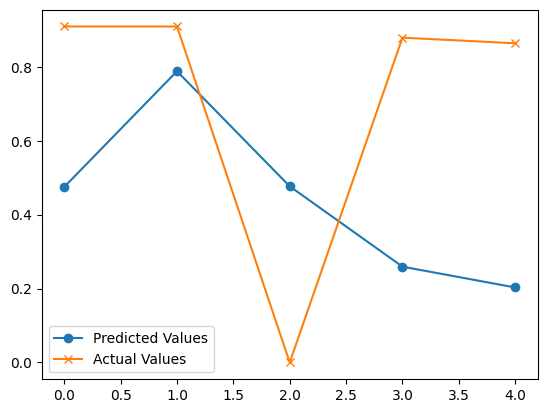

In [13]:
plt.plot(predictions.numpy(), label="Predicted Values", marker="o")
plt.plot(y_test.numpy(), label="Actual Values", marker="x")
plt.legend()
plt.show()

In [14]:
predicted_org = scaler.inverse_transform(predictions)
y_test_org = scaler.inverse_transform(y_test)

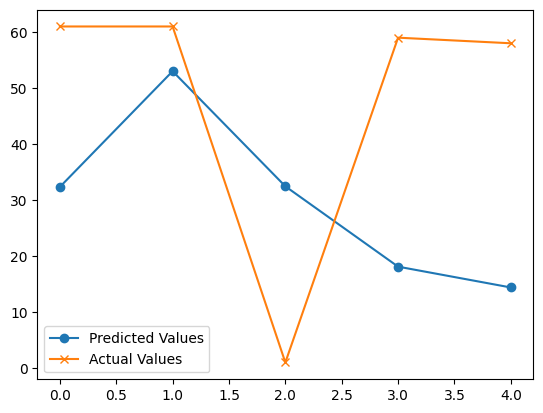

In [15]:
plt.plot(predicted_org, label="Predicted Values", marker="o")
plt.plot(y_test_org, label="Actual Values", marker="x")
plt.legend()
plt.show()

In [16]:
y_test_org

array([[61.00000179],
       [61.00000179],
       [ 1.        ],
       [58.99999976],
       [58.00000072]])

In [17]:
predicted_org

array([[32.35053068],
       [53.01321948],
       [32.45854396],
       [18.11236173],
       [14.39484069]])

In [18]:
predicted_org_up = np.ceil(predicted_org)

In [19]:
predicted_org_up

array([[33.],
       [54.],
       [33.],
       [19.],
       [15.]])

In [20]:
X_test

tensor([[[1.0000],
         [0.0000],
         [0.7576],
         [0.0000],
         [0.8485]],

        [[0.0000],
         [0.8939],
         [0.0000],
         [0.9242],
         [0.0000]],

        [[0.0000],
         [0.9091],
         [0.8333],
         [0.0000],
         [0.8788]],

        [[0.0000],
         [0.7576],
         [0.0000],
         [0.8485],
         [0.9091]],

        [[0.0000],
         [0.9242],
         [0.0000],
         [0.9091],
         [0.9848]]])